In [1]:
import torch
import torch.nn as nn

# ======================
# 固定不变！只训练 Wq
# ======================
# 输入：我 爱
x1 = torch.tensor([1.0, 0.0, 1.0])  # 我
x2 = torch.tensor([0.0, 1.0, 1.0])  # 爱

# 固定 Wk（锁死！不让它变）
Wk_fixed = nn.Parameter(torch.randn(3, 3), requires_grad=False)
k2 = x2 @ Wk_fixed  # 爱 的 K 固定不动

# ======================
# 只有 Wq 是可训练的！
# ======================
Wq = nn.Parameter(torch.randn(3, 3), requires_grad=True)
optimizer = torch.optim.SGD([Wq], lr=0.1)

print("🚀 开始训练：只改 Wq，让 q1 匹配 k2！\n")
for step in range(15):
    optimizer.zero_grad()

    # 1. 只用 Wq 计算 q1（我的查询向量）
    q1 = x1 @ Wq

    # 2. 计算相似度：q1 · k2
    score = torch.dot(q1, k2)

    # 3. 目标：让 score 越大越好 → 所以 Loss 用 -score
    loss = -score

    # ======================
    # 魔法：反向传播改 Wq
    # ======================
    loss.backward()  # 计算梯度：Wq 该怎么改，才能让 score 变大
    optimizer.step()  # 更新 Wq

    print(f"Step {step:2d} | 相似度分数: {score.item():6.2f}")

🚀 开始训练：只改 Wq，让 q1 匹配 k2！

Step  0 | 相似度分数:   3.27
Step  1 | 相似度分数:   3.86
Step  2 | 相似度分数:   4.45
Step  3 | 相似度分数:   5.03
Step  4 | 相似度分数:   5.62
Step  5 | 相似度分数:   6.21
Step  6 | 相似度分数:   6.79
Step  7 | 相似度分数:   7.38
Step  8 | 相似度分数:   7.97
Step  9 | 相似度分数:   8.56
Step 10 | 相似度分数:   9.14
Step 11 | 相似度分数:   9.73
Step 12 | 相似度分数:  10.32
Step 13 | 相似度分数:  10.91
Step 14 | 相似度分数:  11.49


In [3]:
import torch
import torch.nn as nn

# ======================
# 固定不变：q1 锁死
# ======================
x1 = torch.tensor([1.0, 0.0, 1.0])  # 我
x2 = torch.tensor([0.0, 1.0, 1.0])  # 爱

# 固定 Wq，q1 不动
Wq_fixed = nn.Parameter(torch.randn(3, 3), requires_grad=False)
q1 = x1 @ Wq_fixed  # 查询向量固定

# ======================
# 只有 Wk 可训练！！！
# ======================
Wk = nn.Parameter(torch.randn(3, 3), requires_grad=True)
optimizer = torch.optim.SGD([Wk], lr=0.1)

print("🚀 只训练 Wk，让 k2 迎合 q1！\n")
for step in range(15):
    optimizer.zero_grad()

    # 只更新 k2
    k2 = x2 @ Wk

    # 相似度
    score = torch.dot(q1, k2)

    # 目标：score 越大越好
    loss = -score

    # 🔥 反向传播只改 Wk！
    loss.backward()
    optimizer.step()

    print(f"Step {step:2d} | 相似度分数: {score.item():6.2f}")

🚀 只训练 Wk，让 k2 迎合 q1！

Step  0 | 相似度分数:   0.13
Step  1 | 相似度分数:   2.75
Step  2 | 相似度分数:   5.37
Step  3 | 相似度分数:   7.99
Step  4 | 相似度分数:  10.61
Step  5 | 相似度分数:  13.23
Step  6 | 相似度分数:  15.85
Step  7 | 相似度分数:  18.47
Step  8 | 相似度分数:  21.09
Step  9 | 相似度分数:  23.71
Step 10 | 相似度分数:  26.33
Step 11 | 相似度分数:  28.95
Step 12 | 相似度分数:  31.57
Step 13 | 相似度分数:  34.19
Step 14 | 相似度分数:  36.81


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ======================
# 全部固定！只训练 Wv
# ======================
x1 = torch.tensor([1.0, 0.0, 1.0])  # 我
x2 = torch.tensor([0.0, 1.0, 1.0])  # 爱

# 注意力权重固定（假设已经算好：我更关注爱）
attn_weights = torch.tensor([0.7, 0.3])  # 关注我0.7，爱0.3

# ======================
# 只有 Wv 可训练！！！
# ======================
Wv = nn.Parameter(torch.randn(3, 3), requires_grad=True)
optimizer = torch.optim.SGD([Wv], lr=0.1)

# 我们想要的最终输出（随便设一个目标）
target = torch.tensor([5.0, 3.0, 1.0])

print("🚀 只训练 Wv，让输出逼近目标！\n")
for step in range(20):
    optimizer.zero_grad()

    # 1. 只靠 Wv 生成 v1, v2
    v1 = x1 @ Wv
    v2 = x2 @ Wv

    # 2. 注意力加权求和（固定权重）
    out = attn_weights[0] * v1 + attn_weights[1] * v2

    # 3. 计算误差
    loss = F.mse_loss(out, target)

    # 🔥 反向传播只改 Wv！
    loss.backward()
    optimizer.step()

    print(f"Step {step:2d} | Loss: {loss.item():7.4f}")

🚀 只训练 Wv，让输出逼近目标！

Step  0 | Loss:  8.6797
Step  1 | Loss:  6.9475
Step  2 | Loss:  5.5610
Step  3 | Loss:  4.4512
Step  4 | Loss:  3.5628
Step  5 | Loss:  2.8518
Step  6 | Loss:  2.2827
Step  7 | Loss:  1.8271
Step  8 | Loss:  1.4625
Step  9 | Loss:  1.1706
Step 10 | Loss:  0.9370
Step 11 | Loss:  0.7500
Step 12 | Loss:  0.6003
Step 13 | Loss:  0.4805
Step 14 | Loss:  0.3846
Step 15 | Loss:  0.3079
Step 16 | Loss:  0.2464
Step 17 | Loss:  0.1972
Step 18 | Loss:  0.1579
Step 19 | Loss:  0.1264


In [2]:
import torch

!nvidia-smi


print(torch.cuda.is_available())  # Should now be True

print(torch.cuda.get_device_name(0))  # Should say 'NVIDIA GeForce RTX 3060 Ti'

Sun Mar 29 11:14:18 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.97                 Driver Version: 595.97         CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3060 Ti   WDDM  |   00000000:01:00.0  On |                  N/A |
| 30%   32C    P8             15W /  200W |     870MiB /   8192MiB |      3%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [6]:
x = torch.zeros([2,3], device='cuda:0')
print(x.shape)
x = x.transpose(0,1)
print(x.shape)
x = x.to('cuda')
print(x.shape)

torch.Size([2, 3])
torch.Size([3, 2])
torch.Size([3, 2])


In [12]:
x = torch.tensor([[1.,0.], [-1.,1.]], requires_grad=True)

z = x.pow(2).sum()
print(z)
z.backward()
x.grad

tensor(3., grad_fn=<SumBackward0>)


tensor([[ 2.,  0.],
        [-2.,  2.]])

In [14]:
import numpy as np
import random

x_data = [338.0, 333.0, 328.0, 207.0, 226.0, 25.0, 179.0, 60.0, 208.0, 606.0]
y_data = [640.0, 633.0, 619.0, 393.0, 428.0, 27.0, 193.0, 66.0, 226.0, 1591.0]

# 初始化
b = -120
w = -4
lr = 1e-7  # SGD 学习率要小一点
iteration = 10000000

for i in range(iteration):
    # ==================== SGD 核心 ====================
    idx = random.randint(0, 9)  # 随机抽1个样本
    x = x_data[idx]
    y = y_data[idx]

    # 只算这一个样本的梯度
    b_grad = -2 * (y - b - w * x)
    w_grad = -2 * (y - b - w * x) * x

    # 直接更新参数！
    b = b - lr * b_grad
    w = w - lr * w_grad
    # ==================================================

    if i % 10000 == 0:
        print(f"w={w:.2f}, b={b:.2f}")

w=-3.87, b=-120.00
w=2.45, b=-120.01
w=2.51, b=-120.05
w=2.40, b=-120.09
w=2.51, b=-120.13
w=2.53, b=-120.16
w=2.47, b=-120.20
w=2.51, b=-120.24
w=2.48, b=-120.28
w=2.44, b=-120.32
w=2.45, b=-120.36
w=2.45, b=-120.39
w=2.47, b=-120.43
w=2.46, b=-120.47
w=2.38, b=-120.51
w=2.43, b=-120.55
w=2.48, b=-120.58
w=2.50, b=-120.62
w=2.52, b=-120.66
w=2.43, b=-120.70
w=2.56, b=-120.74
w=2.45, b=-120.78
w=2.46, b=-120.81
w=2.46, b=-120.85
w=2.54, b=-120.89
w=2.52, b=-120.93
w=2.54, b=-120.96
w=2.47, b=-121.00
w=2.57, b=-121.04
w=2.38, b=-121.08
w=2.54, b=-121.12
w=2.40, b=-121.15
w=2.53, b=-121.19
w=2.44, b=-121.23
w=2.40, b=-121.27
w=2.45, b=-121.30
w=2.43, b=-121.34
w=2.49, b=-121.38
w=2.48, b=-121.41
w=2.41, b=-121.45
w=2.48, b=-121.49
w=2.43, b=-121.53
w=2.49, b=-121.57
w=2.49, b=-121.60
w=2.52, b=-121.64
w=2.43, b=-121.68
w=2.44, b=-121.72
w=2.43, b=-121.75
w=2.49, b=-121.79
w=2.38, b=-121.82
w=2.46, b=-121.86
w=2.52, b=-121.90
w=2.44, b=-121.94
w=2.49, b=-121.97
w=2.48, b=-122.01
w=2.50, b

In [25]:
import numpy as np
import random

# 原始数据
x_data = np.array([338.0, 333.0, 328.0, 207.0, 226.0, 25.0, 179.0, 60.0, 208.0, 606.0])
y_data = np.array([640.0, 633.0, 619.0, 393.0, 428.0, 27.0, 193.0, 66.0, 226.0, 1591.0])

# 保存原始值，最后反推b
x_raw = x_data.copy()
y_raw = y_data.copy()

# ---------- 关键：数据标准化 ----------
mean_x, std_x = np.mean(x_data), np.std(x_data)
mean_y, std_y = np.mean(y_data), np.std(y_data)
x = (x_data - mean_x) / std_x
y = (y_data - mean_y) / std_y

# 初始化(标准化空间)
w = 0.0
b = 0.0
lr = 0.01
iteration = 20000
batch_size = 3
n = len(x)

for i in range(iteration):
    b_grad = 0.0
    w_grad = 0.0
    batch_idx = random.sample(range(n), batch_size)
    for idx in batch_idx:
        xi = x[idx]
        yi = y[idx]
        error = yi - b - w * xi
        b_grad += -2 * error
        w_grad += -2 * error * xi
    # 用平均梯度
    b_grad /= batch_size
    w_grad /= batch_size

    b = b - lr * b_grad
    w = w - lr * w_grad

# 还原回原始空间的 w、b
w_real = w * std_y / std_x
b_real = mean_y - w_real * mean_x + b * std_y

if i % 2000 == 0:
    print(f"iter={i} | w_real={w_real:.2f}, b_real={b_real:.2f}")

print("\n==== 最终真实参数 ====")
print(f"w = {w_real:.2f}")
print(f"b = {b_real:.2f}")
print("理论最优：w=2.67 , b=-188.4")


==== 最终真实参数 ====
w = 2.69
b = -196.66
理论最优：w=2.67 , b=-188.4


In [9]:
import numpy as np
import random

x_data = [338.0, 333.0, 328.0, 207.0, 226.0, 25.0, 179.0, 60.0, 208.0, 606.0]
y_data = [640.0, 633.0, 619.0, 393.0, 428.0, 27.0, 193.0, 66.0, 226.0, 1591.0]

# 初始化
b = -120.0
w = -4.0
lr = 1e-6  # SGD 学习率要小一点
iteration = 1000000

for i in range(iteration):
    # ==================== SGD 核心 ====================
    b_grad = 0.0
    w_grad = 0.0
    for n in range(len(x_data)):
        b_grad += -2 * (y_data[n] - b - w * x_data[n])
        w_grad += -2 * (y_data[n] - b - w * x_data[n]) * x_data[n]
    # 直接更新参数！
    b = b - lr * b_grad
    w = w - lr * w_grad
    # ==================================================

    if i % 10000 == 0:
        print(f"w={w:.2f}, b={b:.2f}")

w=7.31, b=-119.97
w=2.48, b=-123.69
w=2.49, b=-127.20
w=2.50, b=-130.52
w=2.51, b=-133.66
w=2.52, b=-136.63
w=2.53, b=-139.44
w=2.54, b=-142.09
w=2.54, b=-144.61
w=2.55, b=-146.98
w=2.56, b=-149.23
w=2.56, b=-151.35
w=2.57, b=-153.36
w=2.57, b=-155.27
w=2.58, b=-157.06
w=2.58, b=-158.76
w=2.59, b=-160.37
w=2.59, b=-161.89
w=2.60, b=-163.33
w=2.60, b=-164.69
w=2.60, b=-165.98
w=2.61, b=-167.20
w=2.61, b=-168.35
w=2.61, b=-169.44
w=2.62, b=-170.47
w=2.62, b=-171.44
w=2.62, b=-172.36
w=2.63, b=-173.23
w=2.63, b=-174.06
w=2.63, b=-174.84
w=2.63, b=-175.57
w=2.63, b=-176.27
w=2.64, b=-176.93
w=2.64, b=-177.55
w=2.64, b=-178.14
w=2.64, b=-178.70
w=2.64, b=-179.23
w=2.64, b=-179.73
w=2.65, b=-180.20
w=2.65, b=-180.65
w=2.65, b=-181.07
w=2.65, b=-181.47
w=2.65, b=-181.85
w=2.65, b=-182.20
w=2.65, b=-182.54
w=2.65, b=-182.86
w=2.65, b=-183.16
w=2.66, b=-183.45
w=2.66, b=-183.72
w=2.66, b=-183.97
w=2.66, b=-184.22
w=2.66, b=-184.44
w=2.66, b=-184.66
w=2.66, b=-184.86
w=2.66, b=-185.06
w=2.66, b=

In [26]:
import numpy as np
import random

x_data = np.array([338.0, 333.0, 328.0, 207.0, 226.0, 25.0, 179.0, 60.0, 208.0, 606.0])
y_data = np.array([640.0, 633.0, 619.0, 393.0, 428.0, 27.0, 193.0, 66.0, 226.0, 1591.0])

# 初始化
b = -120.0
w = -4.0
lr = 1.0  # AdaGrad 可以用大学习率！
iteration = 100000

# AdaGrad 专用：累积梯度平方
b_hist = 0.0
w_hist = 0.0

for i in range(iteration):
    b_grad = 0.0
    w_grad = 0.0
    # 全批量 BGD（最稳）
    for n in range(len(x_data)):
        error = y_data[n] - b - w * x_data[n]
        b_grad += -2 * error
        w_grad += -2 * error * x_data[n]

    # ========== AdaGrad 核心 ==========
    b_hist += b_grad**2
    w_hist += w_grad**2

    b -= lr / (np.sqrt(b_hist) + 1e-10) * b_grad
    w -= lr / (np.sqrt(w_hist) + 1e-10) * w_grad

    if i % 10000 == 0:
        print(f"iter={i:6d} | w={w:.2f}, b={b:.2f}")

print("\n===== 最终结果 =====")
print(f"w = {w:.2f}")
print(f"b = {b:.2f}")
print("理论最优：w=2.67, b=-188.4")

iter=     0 | w=-3.00, b=-119.00
iter= 10000 | w=2.57, b=-152.51
iter= 20000 | w=2.62, b=-170.71
iter= 30000 | w=2.64, b=-179.63
iter= 40000 | w=2.66, b=-184.06
iter= 50000 | w=2.66, b=-186.26
iter= 60000 | w=2.67, b=-187.35
iter= 70000 | w=2.67, b=-187.89
iter= 80000 | w=2.67, b=-188.17
iter= 90000 | w=2.67, b=-188.30

===== 最终结果 =====
w = 2.67
b = -188.37
理论最优：w=2.67, b=-188.4


In [27]:
import numpy as np

x_data = np.array([338.0, 333.0, 328.0, 207.0, 226.0, 25.0, 179.0, 60.0, 208.0, 606.0])
y_data = np.array([640.0, 633.0, 619.0, 393.0, 428.0, 27.0, 193.0, 66.0, 226.0, 1591.0])

# 初始化
b = -120.0
w = -4.0
lr = 0.001  # Adam 专用学习率
iteration = 100000

# Adam 超参数
beta1 = 0.9
beta2 = 0.999
eps = 1e-10

# Adam 动量
m_b, m_w = 0.0, 0.0
v_b, v_w = 0.0, 0.0
t = 0

for i in range(iteration):
    t += 1
    b_grad = 0.0
    w_grad = 0.0

    for n in range(len(x_data)):
        error = y_data[n] - b - w * x_data[n]
        b_grad += -2 * error
        w_grad += -2 * error * x_data[n]

    # ========== Adam 核心 ==========
    m_b = beta1 * m_b + (1 - beta1) * b_grad
    m_w = beta1 * m_w + (1 - beta1) * w_grad

    v_b = beta2 * v_b + (1 - beta2) * (b_grad**2)
    v_w = beta2 * v_w + (1 - beta2) * (w_grad**2)

    m_b_hat = m_b / (1 - beta1**t)
    m_w_hat = m_w / (1 - beta1**t)

    v_b_hat = v_b / (1 - beta2**t)
    v_w_hat = v_w / (1 - beta2**t)

    b -= lr / (np.sqrt(v_b_hat) + eps) * m_b_hat
    w -= lr / (np.sqrt(v_w_hat) + eps) * m_w_hat

    if i % 10000 == 0:
        print(f"iter={i:6d} | w={w:.2f}, b={b:.2f}")

print("\n===== 最终结果 =====")
print(f"w = {w:.2f}")
print(f"b = {b:.2f}")
print("理论最优：w=2.67, b=-188.4")

iter=     0 | w=-4.00, b=-120.00
iter= 10000 | w=2.43, b=-113.88
iter= 20000 | w=2.48, b=-121.62
iter= 30000 | w=2.51, b=-131.47
iter= 40000 | w=2.53, b=-141.28
iter= 50000 | w=2.56, b=-151.05
iter= 60000 | w=2.59, b=-160.76
iter= 70000 | w=2.62, b=-170.35
iter= 80000 | w=2.64, b=-179.66
iter= 90000 | w=2.67, b=-187.61

===== 最终结果 =====
w = 2.67
b = -188.43
理论最优：w=2.67, b=-188.4


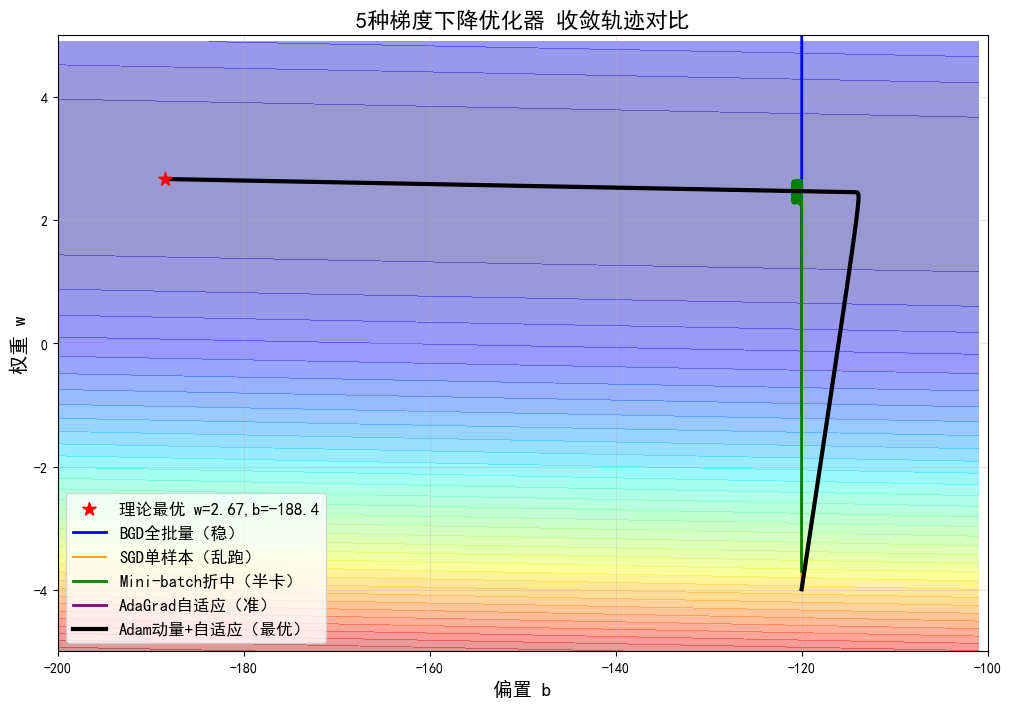

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import random

plt.rcParams["font.family"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

# 原始数据
x_data = np.array([338.0, 333.0, 328.0, 207.0, 226.0, 25.0, 179.0, 60.0, 208.0, 606.0])
y_data = np.array([640.0, 633.0, 619.0, 393.0, 428.0, 27.0, 193.0, 66.0, 226.0, 1591.0])
N = len(x_data)

# ========== 1. 预计算损失曲面Z（等高线背景） ==========
b_range = np.arange(-200, -100, 1)
w_range = np.arange(-5, 5, 0.1)
Xb, Yw = np.meshgrid(b_range, w_range)
Z = np.zeros_like(Xb)
for i in range(len(w_range)):
    for j in range(len(b_range)):
        b = b_range[j]
        w = w_range[i]
        loss = np.sum((y_data - b - w * x_data) ** 2) / N
        Z[i, j] = loss


# ========== 2. 封装5种优化迭代，记录轨迹 ==========
def run_bgd():
    b, w = -120, -4
    lr = 1e-6
    ep = 30000
    hist = []
    for _ in range(ep):
        bg, wg = 0, 0
        for n in range(N):
            e = y_data[n] - b - w * x_data[n]
            bg += -2 * e
            wg += -2 * e * x_data[n]
        b -= lr * bg
        w -= lr * wg
        hist.append([b, w])
    return np.array(hist)


def run_sgd():
    b, w = -120, -4
    lr = 1e-7
    ep = 80000
    hist = []
    for _ in range(ep):
        idx = random.randint(0, N - 1)
        x, y = x_data[idx], y_data[idx]
        e = y - b - w * x
        bg = -2 * e
        wg = -2 * e * x
        b -= lr * bg
        w -= lr * wg
        hist.append([b, w])
    return np.array(hist)


def run_minibatch():
    b, w = -120, -4
    lr = 5e-7
    bs = 3
    ep = 50000
    hist = []
    for _ in range(ep):
        bg, wg = 0, 0
        ids = random.sample(range(N), bs)
        for idx in ids:
            e = y_data[idx] - b - w * x_data[idx]
            bg += -2 * e
            wg += -2 * e * x_data[idx]
        bg /= bs
        wg /= bs
        b -= lr * bg
        w -= lr * wg
        hist.append([b, w])
    return np.array(hist)


def run_adagrad():
    b, w = -120, -4
    lr = 1
    ep = 30000
    eps = 1e-10
    bh, wh = 0, 0
    hist = []
    for _ in range(ep):
        bg, wg = 0, 0
        for n in range(N):
            e = y_data[n] - b - w * x_data[n]
            bg += -2 * e
            wg += -2 * e * x_data[n]
        bh += bg**2
        wh += wg**2
        b -= lr / (np.sqrt(bh) + eps) * bg
        w -= lr / (np.sqrt(wh) + eps) * wg
        hist.append([b, w])
    return np.array(hist)


def run_adam():
    b, w = -120, -4
    lr = 0.01
    ep = 30000
    eps = 1e-10
    b1, b2 = 0.9, 0.999
    mb, mw, vb, vw = 0, 0, 0, 0
    t = 0
    hist = []
    for _ in range(ep):
        t += 1
        bg, wg = 0, 0
        for n in range(N):
            e = y_data[n] - b - w * x_data[n]
            bg += -2 * e
            wg += -2 * e * x_data[n]
        mb = b1 * mb + (1 - b1) * bg
        mw = b1 * mw + (1 - b1) * wg
        vb = b2 * vb + (1 - b2) * (bg**2)
        vw = b2 * vw + (1 - b2) * (wg**2)
        mbt = mb / (1 - b1**t)
        mwt = mw / (1 - b1**t)
        vbt = vb / (1 - b2**t)
        vwt = vw / (1 - b2**t)
        b -= lr / (np.sqrt(vbt) + eps) * mbt
        w -= lr / (np.sqrt(vwt) + eps) * mwt
        hist.append([b, w])
    return np.array(hist)


# 跑5条轨迹
h_bgd = run_bgd()
h_sgd = run_sgd()
h_mb = run_minibatch()
h_ada = run_adagrad()
h_adam = run_adam()

# ========== 3. 绘图对比 ==========
plt.figure(figsize=(12, 8))
# 损失等高线
plt.contourf(b_range, w_range, Z, 50, alpha=0.4, cmap="jet")
# 理论最优解红点
plt.scatter(
    -188.4, 2.67, c="red", s=100, marker="*", label="理论最优 w=2.67,b=-188.4", zorder=5
)

# 画5条轨迹
plt.plot(h_bgd[:, 0], h_bgd[:, 1], c="blue", lw=2, label="BGD全批量（稳）")
plt.plot(h_sgd[:, 0], h_sgd[:, 1], c="orange", lw=1.5, label="SGD单样本（乱跑）")
plt.plot(h_mb[:, 0], h_mb[:, 1], c="green", lw=2, label="Mini-batch折中（半卡）")
plt.plot(h_ada[:, 0], h_ada[:, 1], c="purple", lw=2, label="AdaGrad自适应（准）")
plt.plot(h_adam[:, 0], h_adam[:, 1], c="black", lw=3, label="Adam动量+自适应（最优）")

plt.xlabel("偏置 b", fontsize=14)
plt.ylabel("权重 w", fontsize=14)
plt.title("5种梯度下降优化器 收敛轨迹对比", fontsize=16)
plt.xlim(-200, -100)
plt.ylim(-5, 5)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.show()